# GRAPH CONVOLUTIONAL NEURAL NETWORK - MULTIHEAD ATTENTION VALIDATION

## PARAMETER CONFIGURATION

In [1]:
batch_size = 1
# When splitting the dataset in frames
data_files = [
    # FP11
    {"name": "FP11", "label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP11", "label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP11", "label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_2/TRAJ-150ns.nc"},
    # FP12
    {"name": "FP12", "label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP12", "label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP12", "label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-150ns.nc"},
    #FP18
    {"name": "FP18", "label": [0], "topology_filename": "../FP18_antagonistbox/SYSTEMns.prmtop", "coordinates_filename": "../FP18_antagonistbox/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP18", "label": [0], "topology_filename": "../FP18_antagonistbox/SYSTEMns.prmtop", "coordinates_filename": "../FP18_antagonistbox/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP18", "label": [0], "topology_filename": "../FP18_antagonistbox/SYSTEMns.prmtop", "coordinates_filename": "../FP18_antagonistbox/PRODUCTION_2/TRAJ-150ns.nc"},
    #FP7
    {"name": "FP7", "label": [1], "topology_filename": "../FP7/SYSTEMns.prmtop", "coordinates_filename": "../FP7/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP7", "label": [1], "topology_filename": "../FP7/SYSTEMns.prmtop", "coordinates_filename": "../FP7/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP7", "label": [1], "topology_filename": "../FP7/SYSTEMns.prmtop", "coordinates_filename": "../FP7/PRODUCTION_2/TRAJ-150ns.nc"}
]

epochs = 25
lr = 0.0001
test_size = 0.20
random_state = 42

In [2]:
data_files

[{'name': 'FP11',
  'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_0/TRAJ-150ns.nc'},
 {'name': 'FP11',
  'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_1/TRAJ-150ns.nc'},
 {'name': 'FP11',
  'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_2/TRAJ-150ns.nc'},
 {'name': 'FP12',
  'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-150ns.nc'},
 {'name': 'FP12',
  'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-150ns.nc'},
 {'name': 'FP12',
  'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '.

In [3]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch.nn import Embedding, CrossEntropyLoss, Linear, ReLU, Sequential
import torch.nn.functional as F
from torch_geometric.nn import GATConv, AttentionalAggregation, radius_graph
from sklearn.model_selection import train_test_split, KFold

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import json

/usr/local/jupyter-env/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /usr/local/jupyter-env/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/usr/local/jupyter-env/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/jupyter-env/lib/python3.10/site-packages/torch_scatter/_scatter_cuda.so: undefined symbol: _ZN2at4_ops16div__Tensor_mode4callERNS_6TensorERKS2_St8optionalIN3c1017basic_string_viewIcEEE
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/jupyter-env/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /

In [4]:
torch.cuda.is_available()

True

## DATA LOAD

In [5]:
# u = mda.Universe("../data/md-2025-03-11/FP11ns.prmtop", "../data/md-2025-03-11/FP11-150ns.nc")
# residue_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('name CA').resnames).tolist()))
# atom_type_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('protein').atoms.types.tolist())))

with open('atom-list.json') as f: 
    atom_type_index = json.load(f)
with open('residue-list.json') as f: 
    residue_index = json.load(f)

In [6]:
def trajectory_to_data(u, selection_string, residue_index, atom_type_index, label):
    for fr in u.trajectory:
        x = torch.from_numpy(u.select_atoms(selection_string).positions)
        residues = list(map(lambda x: residue_index[x], u.select_atoms(selection_string).resnames))
        atom_types = list(map(lambda x: atom_type_index[x], u.select_atoms(selection_string).atoms.types.tolist()))
        d = Data(pos=x, res=torch.tensor(residues, dtype=torch.long), types=torch.tensor(atom_types, dtype=torch.long), label=torch.tensor(label, dtype=torch.long))
        yield d

## DATA SPLITTING

In [7]:
compound_groups = {
    "group1": {
        "selection_string": "resid 613:754 and name CA N C O",
        "compounds": ["FP11", "FP12"]
    },
    "group2": {
        "selection_string": "resid 9:150 and name CA N C O",
        "compounds": ["FP18"]
    },
    "group3": {
        "selection_string": "resid 612:753 and name CA N C O",
        "compounds": ["FP7"]
    }
}

In [ ]:
compound_groups = {
    "group1": {
        "selection_string": "resid 618 626 627 628 638 640 642 646 655 657 659 661 665 670 672 674 675 684 686 688 696 698 707 709 711 712 713 714 715 716 717 718 720 725 726 727 729 740 741 743 745 746 747",
        "compounds": ["FP11", "FP12"]
    },
    "group2": {
        "selection_string": "resid 14 22 23 24 34 36 38 42 51 53 55 57 61 66 68 70 71 80 82 84 92 94 103 105 107 108 109 110 111 112 113 114 116 121 122 123 125 136 137 139 141 142 143",
        "compounds": ["FP18"]
    },
    "group3": {
        "selection_string": "resid 617 625 626 627 637 639 641 645 654 656 658 660 664 669 671 673 674 683 685 687 695 697 706 708 710 711 712 713 714 715 716 717 719 724 725 726 728 739 740 742 744 745 746",
        "compounds": ["FP7"]
    }
}

In [8]:
trj = []

for group in compound_groups.values():
    selection_string = group["selection_string"]
    for file in data_files:
        if file["name"] in group["compounds"]:
            u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
            trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
            print(file['coordinates_filename']) # to check all files are read correctly
            print(len(u.trajectory)) # to check there are 1500 frames per file

print("")
print(len(trj))

../FP11_monomer/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP11_monomer/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP11_monomer/PRODUCTION_2/TRAJ-150ns.nc
1500
../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-150ns.nc
1500
../FP18_antagonistbox/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP18_antagonistbox/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP18_antagonistbox/PRODUCTION_2/TRAJ-150ns.nc
1500
../FP7/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP7/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP7/PRODUCTION_2/TRAJ-150ns.nc
1500

18000


In [9]:
trj[:5]

[Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1])]

### Random Split

In [10]:
train_trj, test_trj = train_test_split(trj, test_size=test_size, random_state=random_state)

In [11]:
len(train_trj)

14400

In [12]:
len(test_trj)

3600

### Frame Data Splitting

#### First 750 frames for training and last 750 frames for test

In [ ]:
# First 750 frames for training and last 750 frames for test
frames_per_simulation = 1500
chunk_size = 750

train_trj = []
test_trj = []

# 
for i in range(0, len(trj), frames_per_simulation):
    simulation_frames = trj[i:i + frames_per_simulation] # Extract the current simulation frames
    train_trj.extend(simulation_frames[:chunk_size]) # First 750 frames to train
    test_trj.extend(simulation_frames[chunk_size:]) # Last 750 frames to test

In [ ]:
len(train_trj)

In [ ]:
len(test_trj)

#### Split simulation data every 100 frames

In [ ]:
# Split every 100 frames
frames_per_simulation = 1500
chunk_size = 100

train_trj = []
test_trj = []

for i in range(0, len(trj), frames_per_simulation):
    simulation_frames = trj[i:i + frames_per_simulation] # Extract the current simulation frames
    for j in range(0, frames_per_simulation, chunk_size): 
        chunk = simulation_frames[j:j + chunk_size] # Iterate each 100 frames
        if(j // chunk_size) % 2 == 0: # If index of chunk is even (0, 2, 4, etc) go to train
            train_trj.extend(chunk)
        else:
            test_trj.extend(chunk) # If odd (1, 3, 5, etc) go to test

In [ ]:
len(train_trj)

In [ ]:
len(test_trj)

## MODEL

In [13]:
class GAT(torch.nn.Module):
    def __init__(self, radius=5.0, num_heads=4):
        super().__init__()
        self.radius = radius
        self.num_heads = num_heads
        self.embed_res = Embedding(num_embeddings=24, embedding_dim=128)
        self.embed_type = Embedding(num_embeddings=33, embedding_dim=128)
        # RESDIUE TYPE BRANCH
        self.gat1_res = GATConv(128, 16, heads=num_heads, concat=True)
        self.relu1_res = ReLU()
        self.gat2_res = GATConv(16*num_heads, 16, heads=1, concat=False)
        self.relu2_res = ReLU()
        self.gat3_res = GATConv(16, 16, heads=1, concat=False)
        # ATOM TYPE BRANCH
        self.gat1_type = GATConv(128, 16, heads=num_heads, concat=True)
        self.relu1_type = ReLU()
        self.gat2_type = GATConv(16*num_heads, 16, heads=1, concat=False)
        self.relu2_type = ReLU()
        self.gat3_type = GATConv(16, 16, heads=1, concat=False)
        # ATTENTION MECHANISM IN POOLING LAYER
        self.pool_res = AttentionalAggregation(gate_nn=Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        self.pool_type = AttentionalAggregation(gate_nn=Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        # LINEAR LAYER
        self.linear1 = Linear(32, 2)

    def forward(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        edge_index = radius_graph(pos, r=self.radius, batch=batch)
        # FORWARD PASS OF RESIDUES TYPES
        z_res = self.embed_res(res)
        z_res = self.relu1_res(self.gat1_res(z_res, edge_index))
        z_res = self.relu2_res(self.gat2_res(z_res, edge_index))
        z_res = self.gat3_res(z_res, edge_index)
        # FORWARD PASS OF ATOMS TYPES
        z_type = self.embed_type(type)
        z_type = self.relu1_type(self.gat1_type(z_type, edge_index))
        z_type = self.relu2_type(self.gat2_type(z_type, edge_index))
        z_type = self.gat3_type(z_type, edge_index)
        # FORWARD PASS POOLING AND LINEAR LAYER
        z_res = self.pool_res(z_res, data.batch)
        z_type = self.pool_type(z_type, data.batch)
        z = torch.cat([z_res, z_type], dim=1)
        z = self.linear1(z)
        #z = F.softmax(z, dim=1) #CrossEntropyLoss already does softmax at the end
        return z

## VALIDATION

In [16]:
gat = GAT().to(torch.device("cuda:0"))
loss = CrossEntropyLoss()
optimizer = torch.optim.Adam(gat.parameters(), lr=lr, weight_decay=5e-4)
train_loader = DataLoader(train_trj, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_trj, batch_size=batch_size, shuffle=True)
history = []
for i in tqdm.tqdm(range(epochs)):
    statistics = dict()
    statistics['training_loss'] = 0.0
    gat.train()
    for d in train_loader:
        d = d.to(torch.device("cuda:0"))
        optimizer.zero_grad()
        z = gat(d)
        l = loss(z, d.label)
        l.backward()
        optimizer.step()
    statistics['training_loss'] += l.item()
    gat.eval()
    with torch.no_grad():
        statistics['test_accuracy'] = 0.0
        statistics['test_loss'] = 0.0
        for d in test_loader:
            d = d.to(torch.device("cuda:0"))
            z = gat(d)
            l = loss(z, d.label)
            a = ((z.argmax(1) == d.label).sum())
            statistics['test_accuracy'] += a.item()
            statistics['test_loss'] += l.item()
                
    statistics['test_accuracy'] /= len(test_trj)
    statistics['test_loss'] /= ((len(test_trj) // batch_size) + 1)

    print(f"Epoch {i+1:2d} | Accuracy {statistics['test_accuracy']:.4f}")
    history.append(statistics)

  4%|███▎                                                                              | 1/25 [08:55<3:34:21, 535.91s/it]

Epoch  1 | Accuracy 0.7178


  8%|██████▌                                                                           | 2/25 [17:56<3:26:28, 538.63s/it]

Epoch  2 | Accuracy 0.7583


 12%|█████████▊                                                                        | 3/25 [27:00<3:18:27, 541.25s/it]

...

Epoch 23 | Accuracy 0.9169


 96%|█████████████████████████████████████████████████████████████████████████████▊   | 24/25 [3:34:53<08:56, 536.72s/it]

Epoch 24 | Accuracy 0.9219


100%|█████████████████████████████████████████████████████████████████████████████████| 25/25 [3:43:35<00:00, 536.64s/it]

Epoch 25 | Accuracy 0.9122


In [17]:
pd.DataFrame.from_records(history)

,training_loss,test_accuracy,test_loss
0,0.620241,0.717778,0.644186
1,0.324134,0.758333,0.495356
2,0.679754,0.767778,0.466345
3,0.174520,0.777778,0.457469
4,0.265177,0.780556,0.454989
5,0.071745,0.789444,0.431654
6,0.129964,0.797778,0.426802
7,0.015299,0.808333,0.412195
8,0.433717,0.834444,0.377971
9,0.305307,0.867500,0.317659


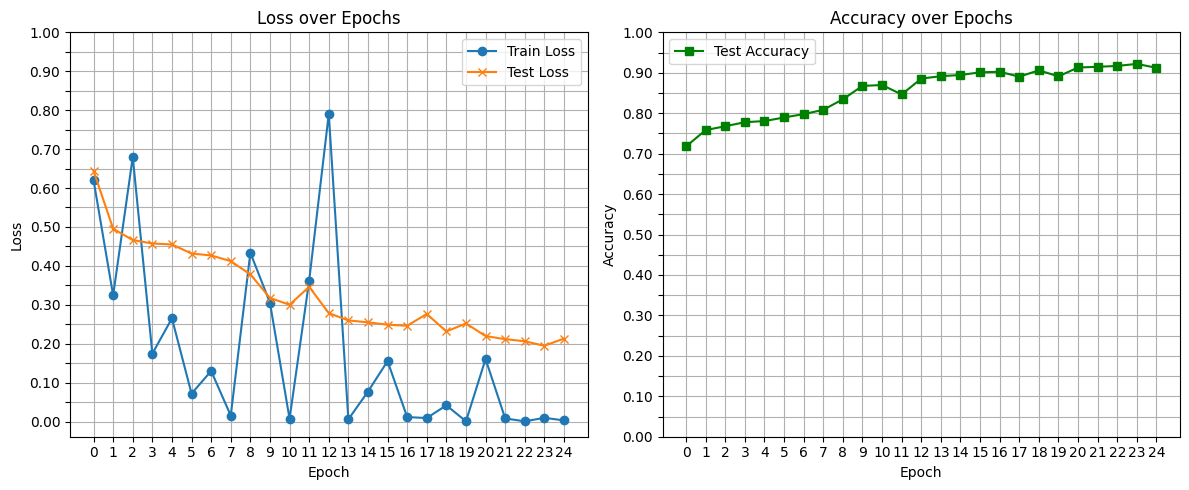

In [19]:
# Plotting the results
train_loss = [h['training_loss'] for h in history]
test_loss = [h['test_loss'] for h in history]
test_accuracy = [h['test_accuracy'] for h in history]
epochs_count = list(range(0, len(history)))
yticks = np.arange(0.0, 1.05, 0.05)
ytick_labels = [f'{y:.2f}' if (int(y*100)%10==0) else '' for y in yticks]
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss', marker='o')
plt.plot(test_loss, label='Test Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_count)
plt.yticks(yticks, ytick_labels)
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(test_accuracy, label='Test Accuracy', marker='s', color='green')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs_count)
plt.yticks(yticks, ytick_labels)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()